In [1]:
print("Hello")

Hello


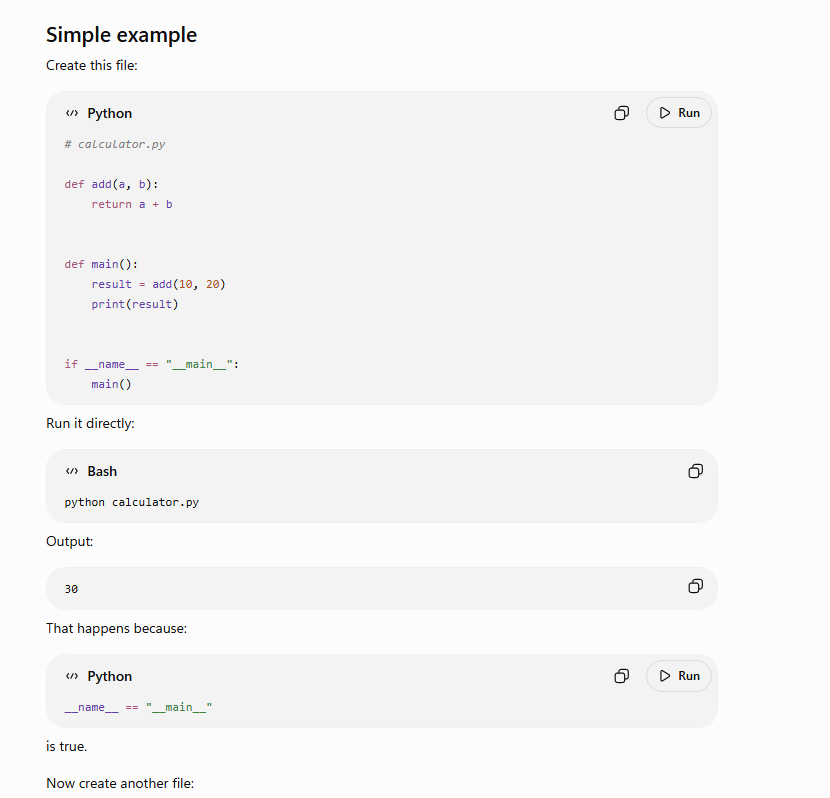

In [2]:
import calculator

In [3]:
!python calculator.py

30


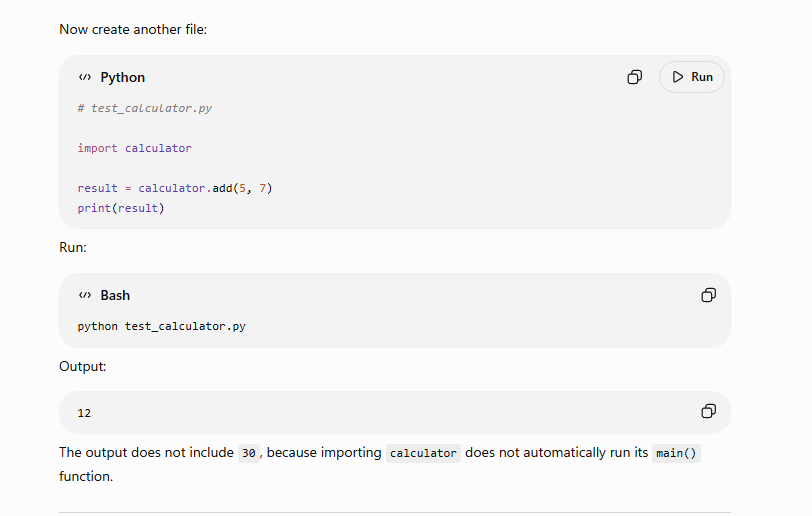

In [4]:
import calculator

result = calculator.add(5,7)
print(result)

12


In [5]:
from sprint_report import _extract_os_version

def test_extract_os_version():
    summary = "The dut running version is 4.29.4M-DPE-CTNR."
    assert _extract_os_version(summary) == "4.29.4M-DPE-CTNR"

ModuleNotFoundError: No module named 'sprint_report'

```python
if __name__ == "__main__":
    main()
```

This is called the **Python entry-point check**. It controls whether the `main()` function should run.

## What is `__name__`?

Python automatically creates a special variable called:

```python
__name__
```

Its value depends on how the Python file is used.

### When the file is executed directly

Suppose the file is named:

```text
sprint_report.py
```

You run it like this:

```bash
python sprint_report.py
```

Python sets:

```python
__name__ = "__main__"
```

Therefore, this condition becomes true:

```python
if "__main__" == "__main__":
```

Then Python executes:

```python
main()
```

So the complete sprint-report process starts.

---

### When the file is imported

Suppose another Python file imports it:

```python
import sprint_report
```

Python sets:

```python
__name__ = "sprint_report"
```

Now the condition becomes:

```python
if "sprint_report" == "__main__":
```

That condition is false, so:

```python
main()
```

does not run automatically.

The functions and variables in the file are still available:

```python
sprint_report.query_runtime(...)
sprint_report.format_html_report(...)
sprint_report.build_client()
```

But the entire report-generation process does not start automatically.

---

# Simple example

Create this file:

```python
# calculator.py

def add(a, b):
    return a + b


def main():
    result = add(10, 20)
    print(result)


if __name__ == "__main__":
    main()
```

Run it directly:

```bash
python calculator.py
```

Output:

```text
30
```

That happens because:

```python
__name__ == "__main__"
```

is true.

Now create another file:

```python
# test_calculator.py

import calculator

result = calculator.add(5, 7)
print(result)
```

Run:

```bash
python test_calculator.py
```

Output:

```text
12
```

The output does not include `30`, because importing `calculator` does not automatically run its `main()` function.

---

# How it works in your sprint-report script

Your script ends with:

```python
if __name__ == "__main__":
    main()
```

When you run:

```bash
python sprint_report.py
```

Python follows this flow:

```text
Load imports
    ↓
Create constants
    ↓
Define all functions
    ↓
Reach the entry-point check
    ↓
Is __name__ equal to "__main__"?
    ↓
Yes
    ↓
Call main()
```

Then `main()` performs the actual work:

```text
Read command-line arguments
        ↓
Calculate sprint dates
        ↓
Authenticate with Azure
        ↓
Connect to Kusto
        ↓
Run Kusto queries
        ↓
Calculate test statistics
        ↓
Print terminal tables
        ↓
Create the HTML report
```

In your file, `main()` starts at line 800, and this entry-point check calls it only when the script is run directly.  

---

# Why not simply write `main()`?

You could write:

```python
main()
```

at the bottom of the file.

That would work when running the file directly. However, it would also run automatically whenever another file imports it.

For example:

```python
import sprint_report
```

Without the entry-point check, importing the module could immediately:

* Authenticate to Azure.
* Run Kusto queries.
* Print reports.
* Create an HTML file.
* Exit if data is missing.

That would be unexpected and problematic.

Using:

```python
if __name__ == "__main__":
    main()
```

prevents those side effects.

---

# Meaning of each line

## First line

```python
if __name__ == "__main__":
```

This asks:

> Is this Python file currently being executed as the main program?

It does not ask whether the function is named `main`. It checks how the Python file was started.

## Second line

```python
    main()
```

This calls the function named `main()`.

Because it is indented, it runs only when the condition above is true.

---

# Important distinction

These two names are unrelated:

```python
__main__
main()
```

`"__main__"` is a special string Python assigns to the directly executed file.

`main()` is an ordinary function created by the programmer. It could technically have any name:

```python
def start_report():
    print("Generating report")


if __name__ == "__main__":
    start_report()
```

This works exactly the same way.

The function name `main` is only a common programming convention.

---

# Execution comparison

| How the file is used                              | Value of `__name__` | Does `main()` run? |
| ------------------------------------------------- | ------------------- | ------------------ |
| `python sprint_report.py`                         | `"__main__"`        | Yes                |
| `python sprint_report.py --sprint-end 2026-07-26` | `"__main__"`        | Yes                |
| `import sprint_report`                            | `"sprint_report"`   | No                 |
| `from sprint_report import query_runtime`         | `"sprint_report"`   | No                 |

---

# Significance

This pattern provides four major benefits.

### Safe importing

Other programs can reuse the functions without automatically running the full script.

### Clear starting point

A reader immediately knows that `main()` is where the program’s execution begins.

### Easier testing

Testing tools can import individual functions without connecting to Kusto or generating reports automatically.

```python
from sprint_report import _extract_os_version

def test_extract_os_version():
    summary = "The dut running version is 4.29.4M-DPE-CTNR."
    assert _extract_os_version(summary) == "4.29.4M-DPE-CTNR"
```

### Better code organization

Instead of placing all execution logic at the top level, the script keeps it inside `main()`. This makes the code easier to read, maintain, and reuse.

The easiest way to remember it is:

```text
Run directly  → execute main()
Imported      → only provide functions and variables
```


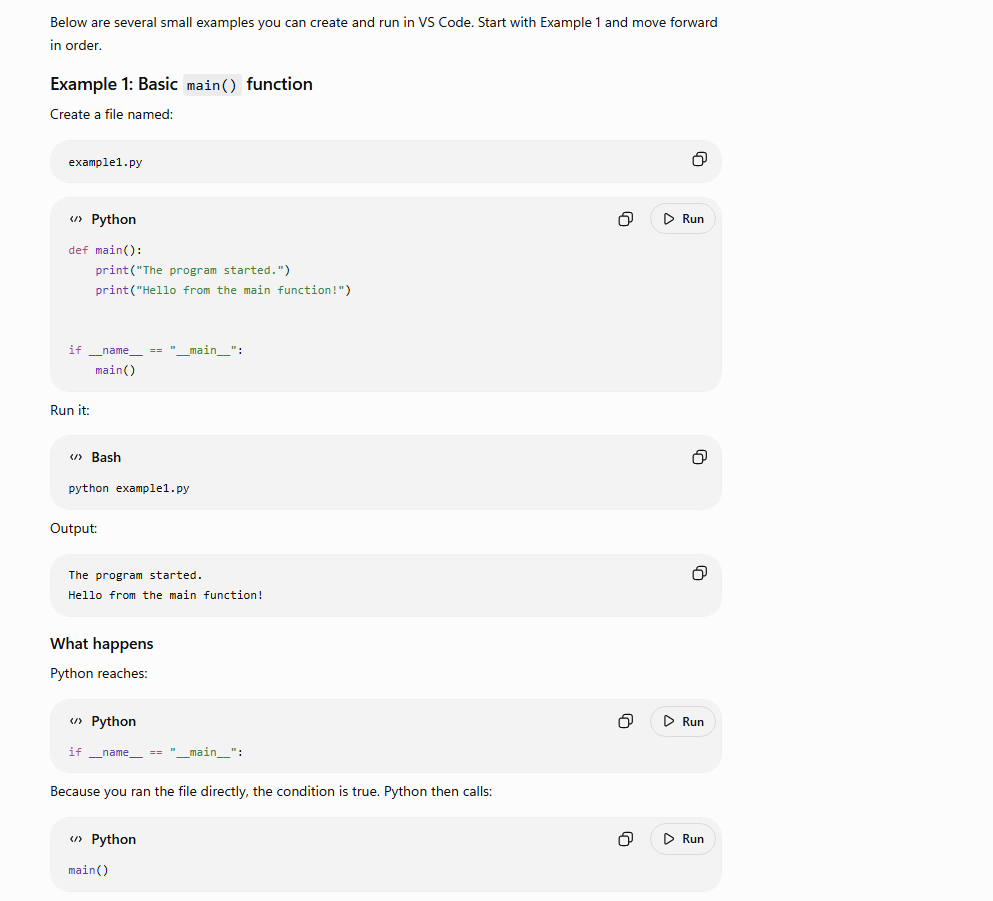

In [8]:
import example1



In [7]:
!python example1.py

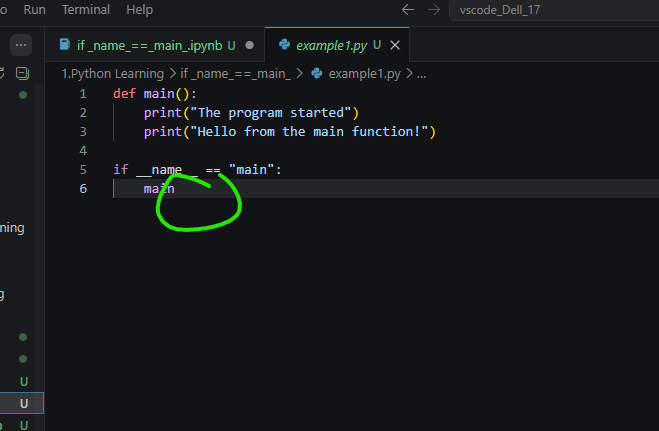

I missed to add main() then we did not see any result. if the above execuation fo code

In [9]:
import example2

In [10]:
!pip example2

ERROR: unknown command "example2"



In [13]:
!python example2.py

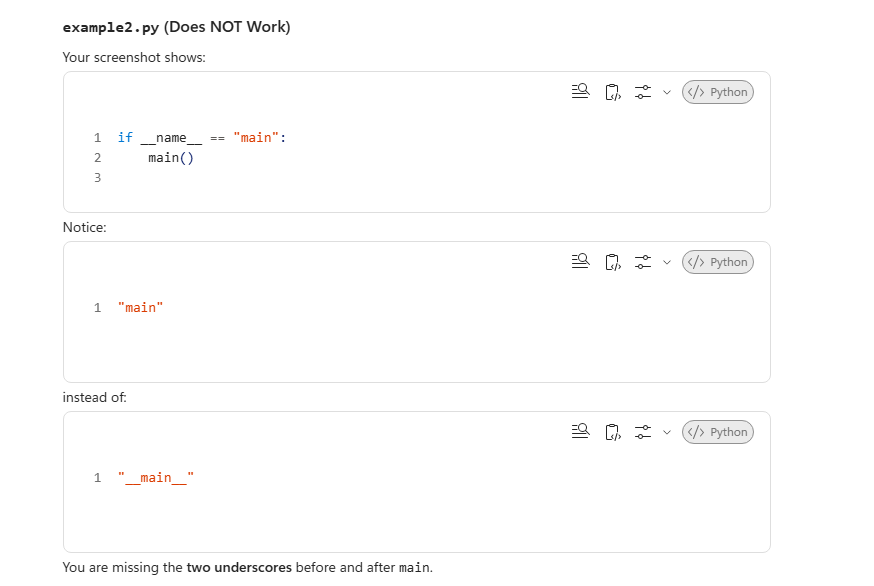

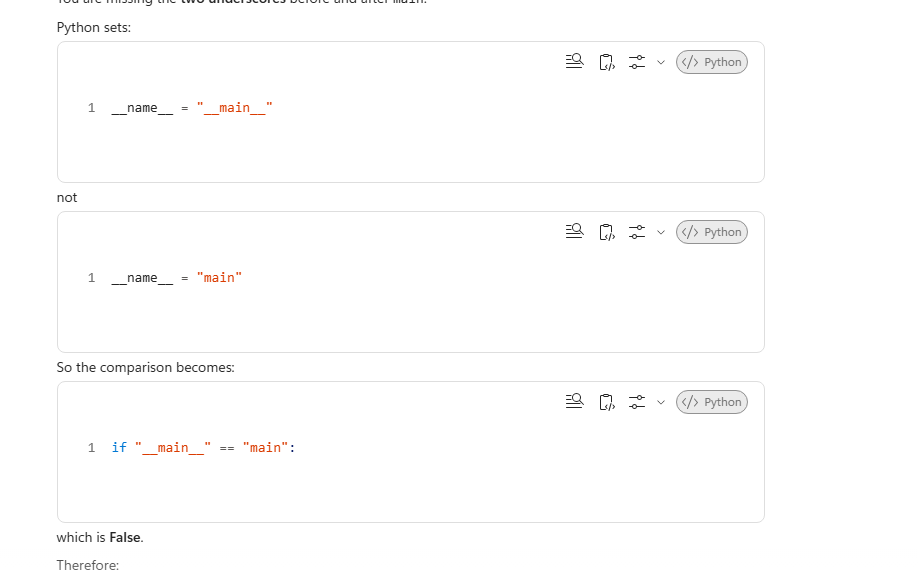

In [14]:
import test

In [15]:
!python test.py

The program started.
Hello from the main function!


In [16]:
import example3

In [17]:
!python example3

python: can't open file 'c:\\Users\\v-yaalam\\Downloads\\vscode_Dell_17\\1.Python Learning\\if _name_==_main_\\example3': [Errno 2] No such file or directory


In [18]:
!python example3.py

The program started
Hello from the main function!


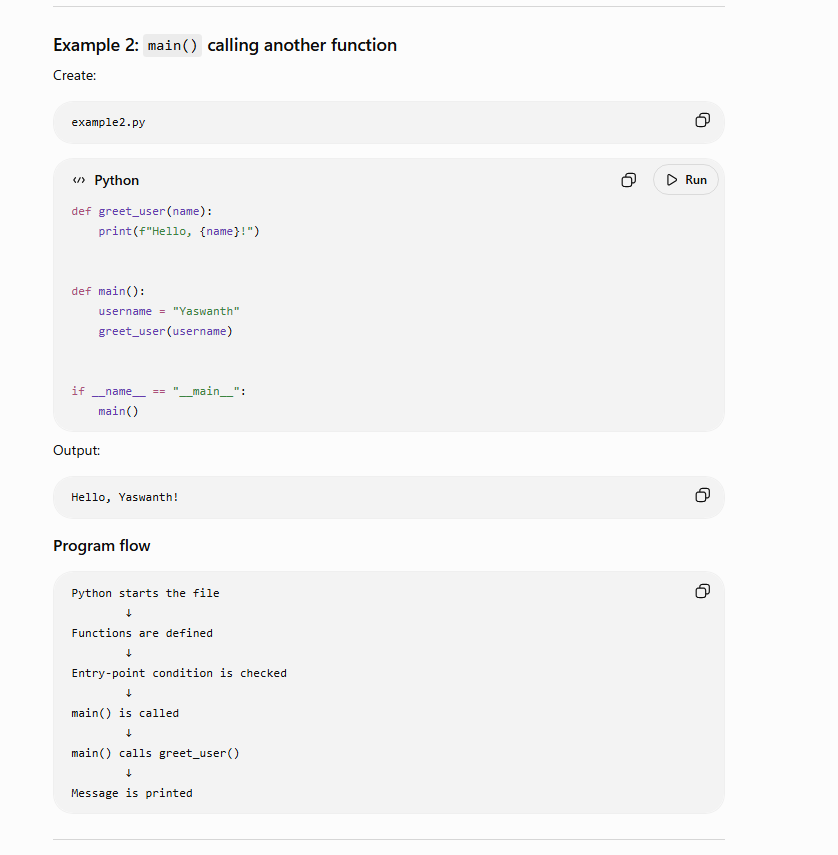

In [19]:
import example4

In [20]:
!python example4.py

hello, Yaswanth!


In [24]:
import example5

In [26]:
!python example5.py

My name is, Yaswanth Alam!!
I am name is Yaswanth Alam


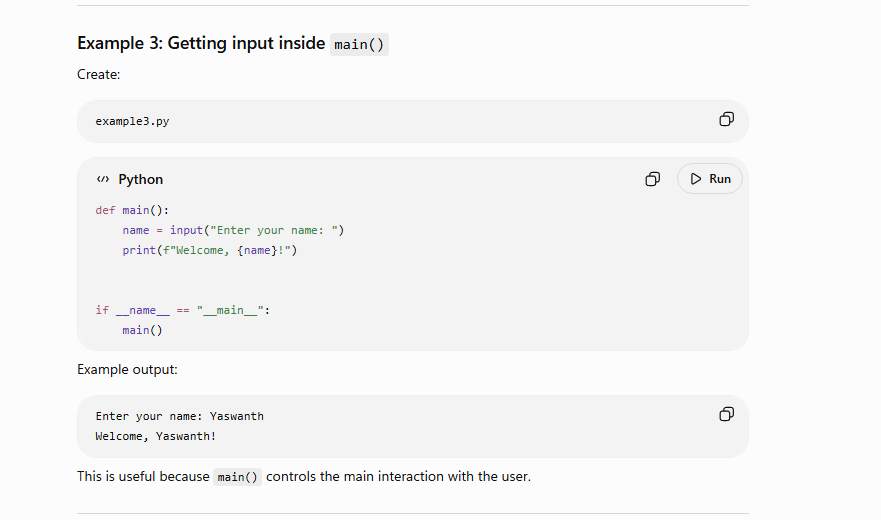

In [30]:
import example6

In [31]:
!python example6.py

^C


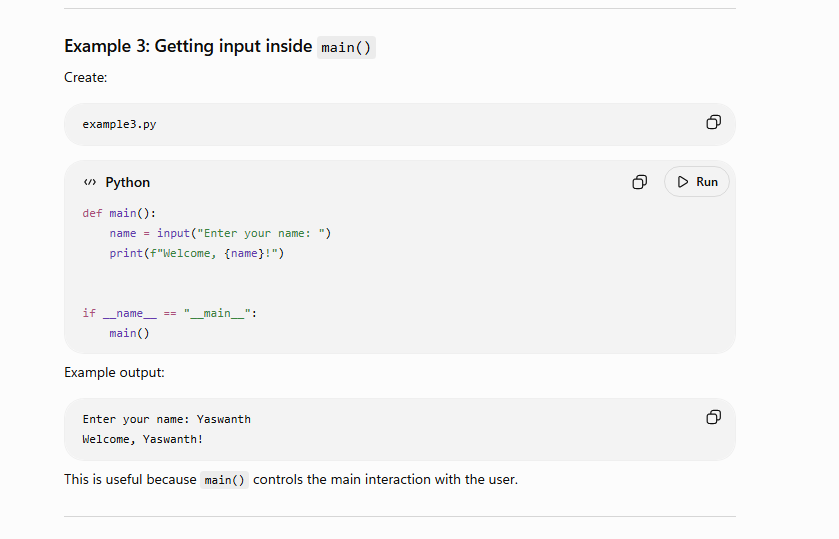

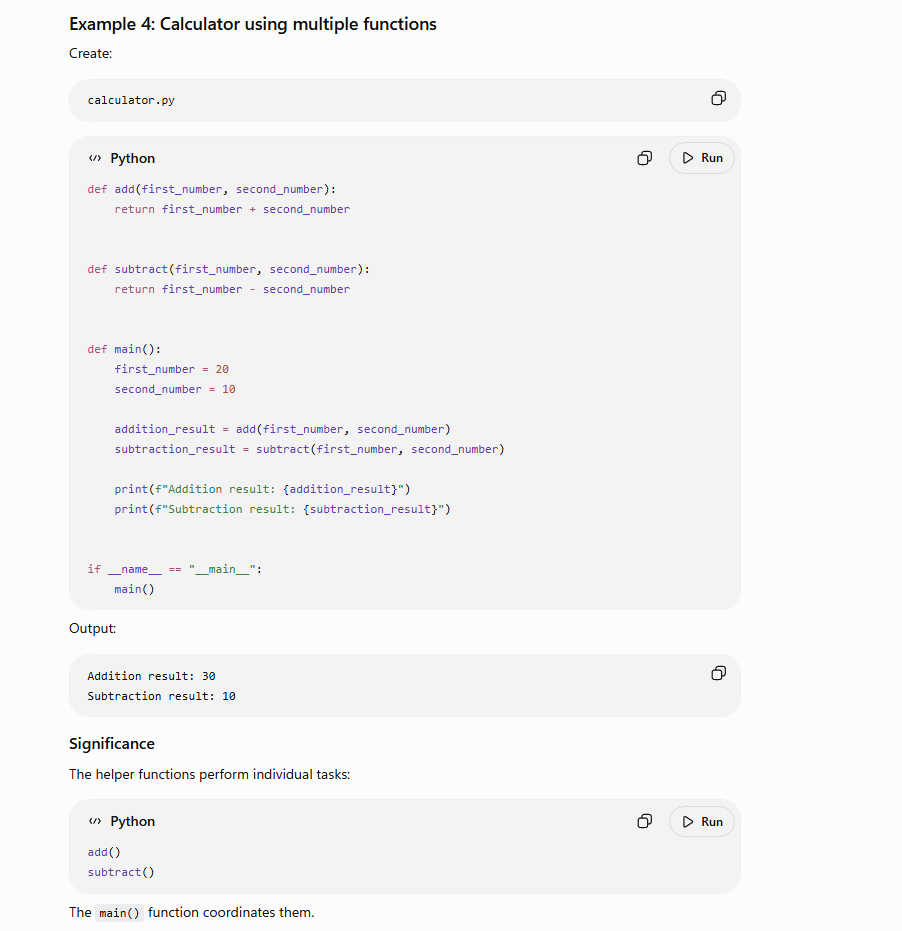

In [32]:
import calculator123


In [33]:
!python calculator123.py

Addition result: 300
Subtraction_result: -100


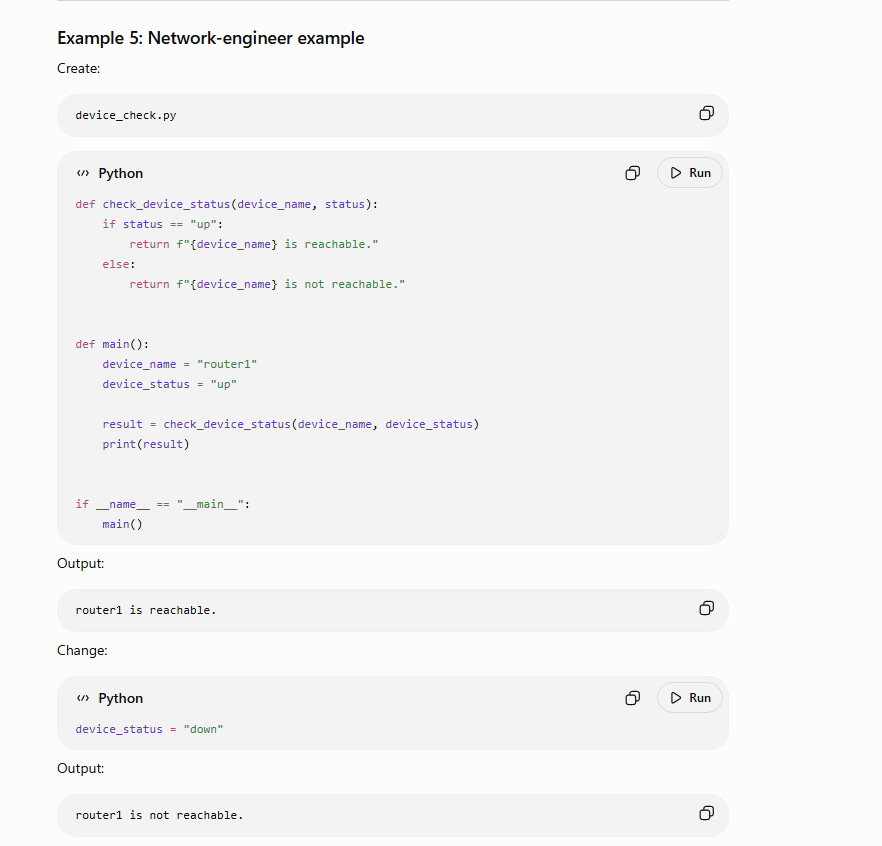

In [34]:
import device_check

In [35]:
!python device_check.py

router1 is reachable


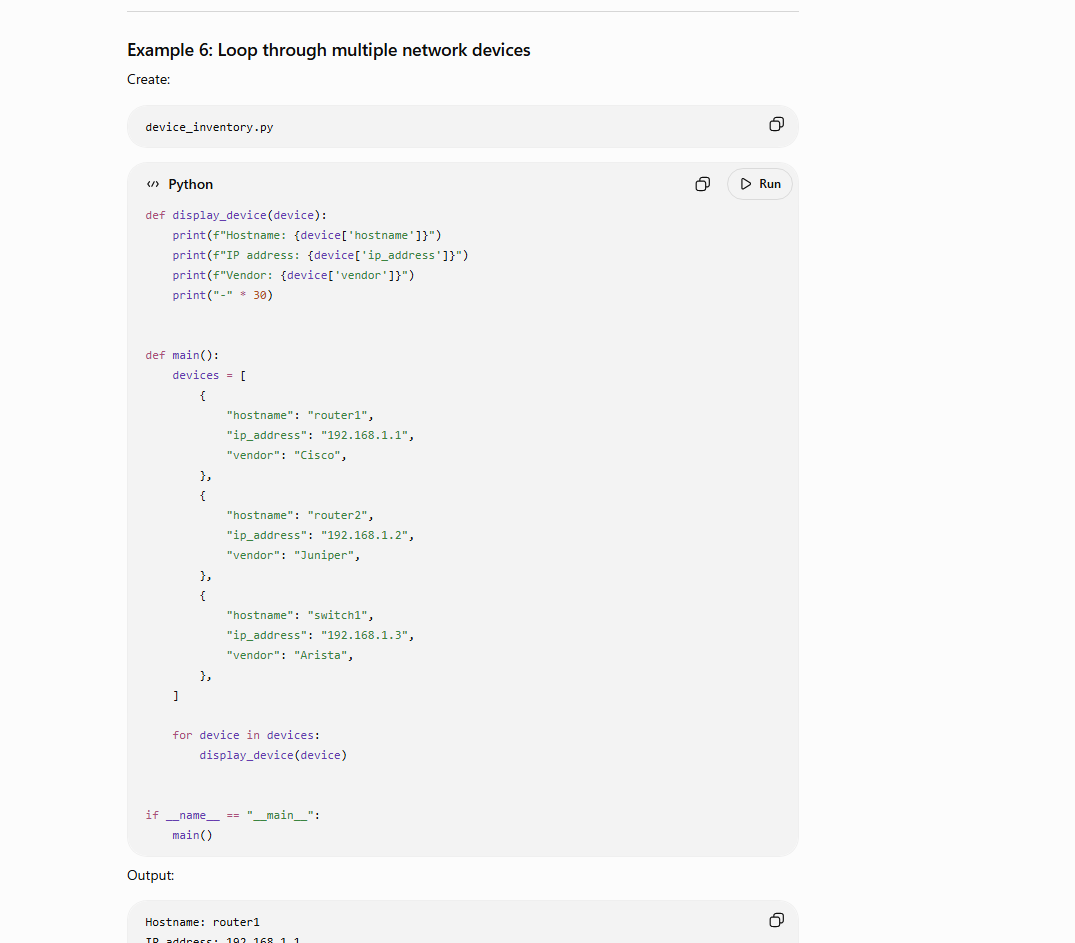

In [36]:
import device_inventory

In [38]:
!python device_inventory.py

Hostname: router1
IP address: 192.168.1.1
vendor: Cisco
------------------------------
Hostname: router2
IP address: 192.168.1.2
vendor: Juniper
------------------------------
Hostname: switch1
IP address: 192.168.1.3
vendor: Arista
------------------------------


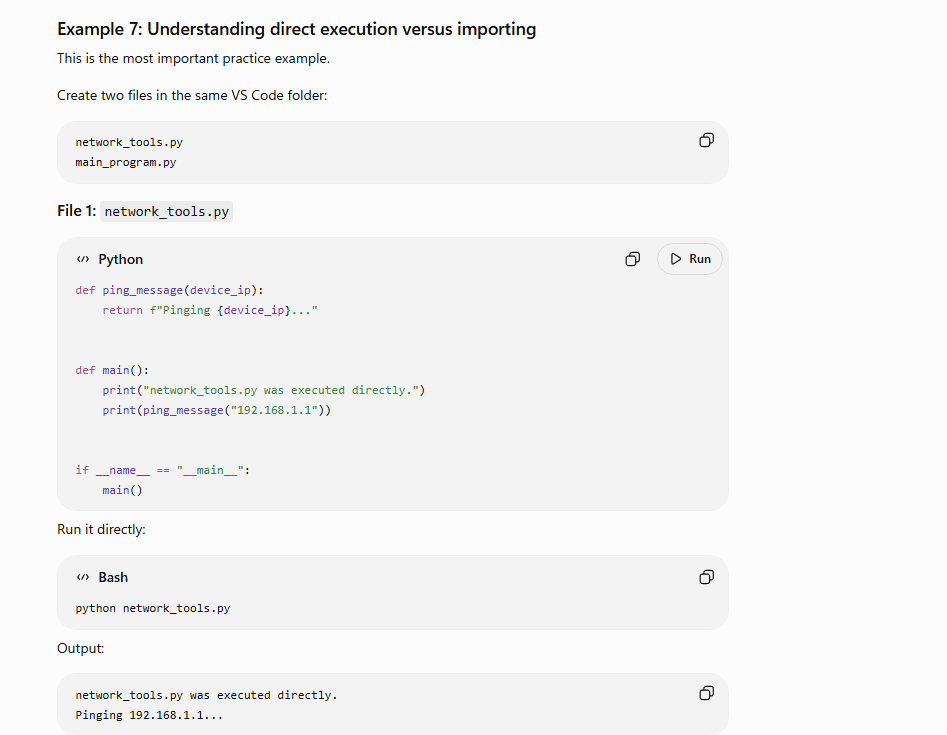

In [39]:
import network_tools

In [40]:
!python network_tools.py

network_tools.py was executed directly
Pinging 192.168.1.1.......................,,,,,,,,,


In [41]:
import main_program

In [42]:
!python main_program.py

Pinging 10.0.0.1.......................,,,,,,,,,


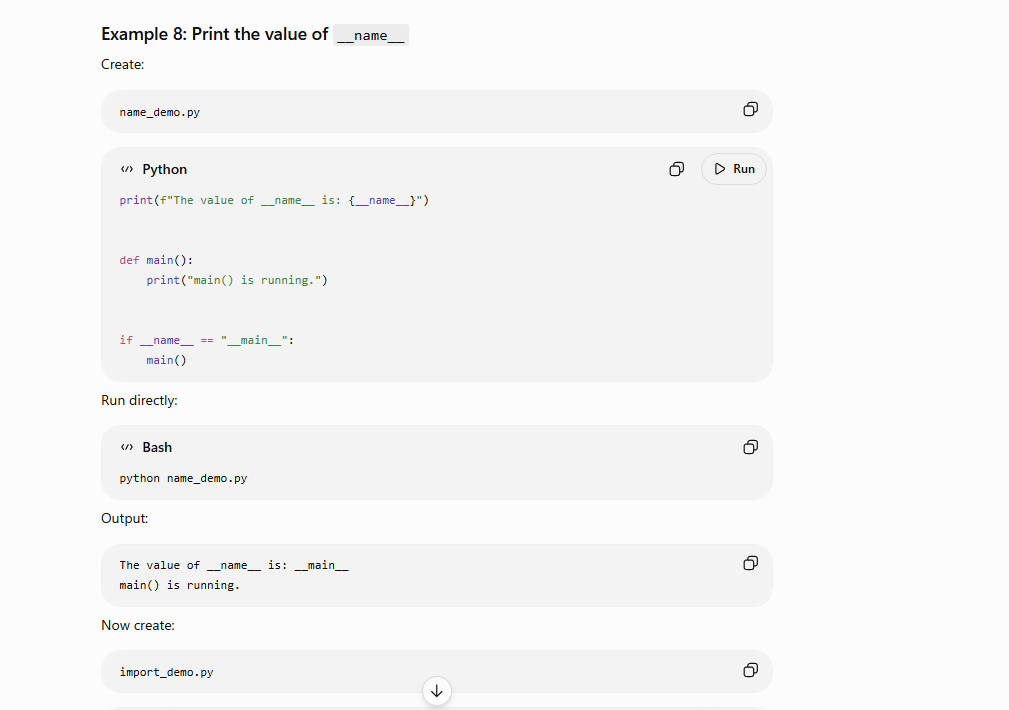

In [43]:
import name_demo

The value of __name__ is: name_demo


In [44]:
!import name_demo

'import' is not recognized as an internal or external command,
operable program or batch file.


In [45]:
!python name_demo.py

The value of __name__ is: __main__
main() is running.


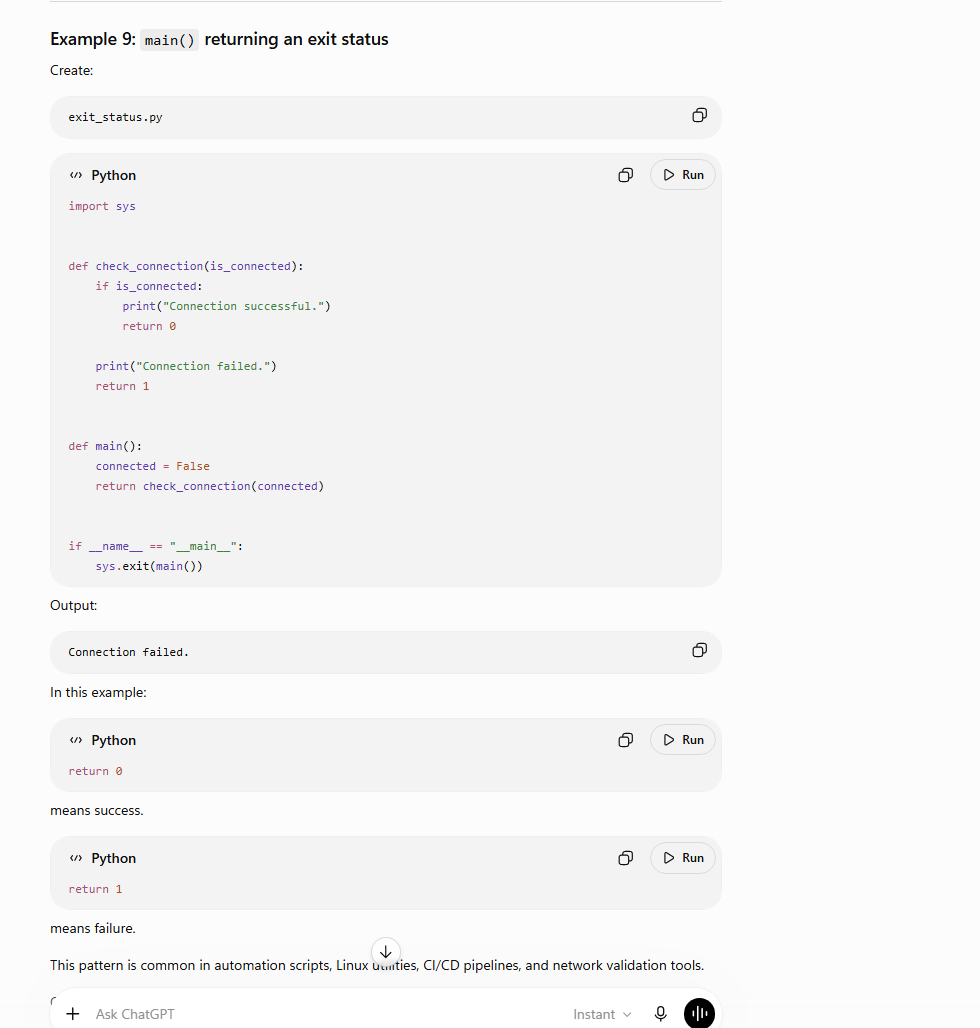

In [1]:
import exit_status

In [2]:
!python exit_status.py

Connection failed.


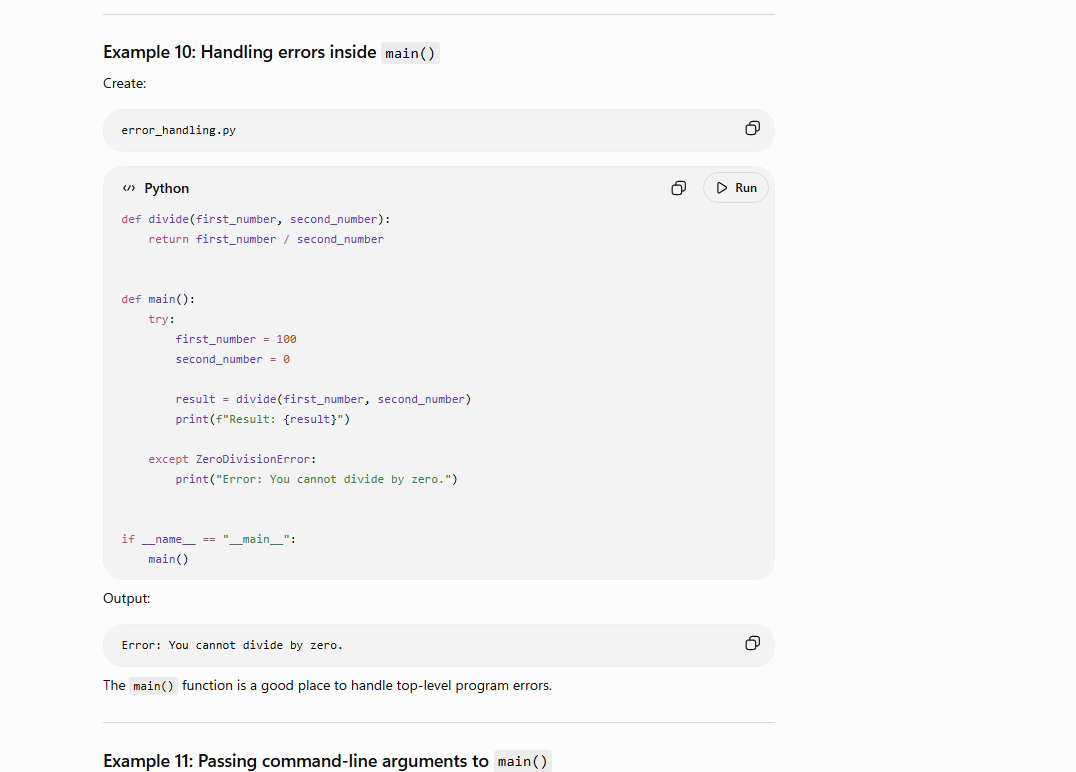

In [3]:
import error_handling

In [4]:
!python error_handling.py

Error: You cannot divide by Zero


In [5]:
!python device_cli.py

usage: device_cli.py [-h] --hostname HOSTNAME --ip IP
device_cli.py: error: the following arguments are required: --hostname, --ip


In [6]:
import device_cli

In [7]:
!python device_cli.py

usage: device_cli.py [-h] --hostname HOSTNAME --ip IP
device_cli.py: error: the following arguments are required: --hostname, --ip


Below are several small examples you can create and run in VS Code. Start with Example 1 and move forward in order.

## Example 1: Basic `main()` function

Create a file named:

```text
example1.py
```

```python
def main():
    print("The program started.")
    print("Hello from the main function!")


if __name__ == "__main__":
    main()
```

Run it:

```bash
python example1.py
```

Output:

```text
The program started.
Hello from the main function!
```

### What happens

Python reaches:

```python
if __name__ == "__main__":
```

Because you ran the file directly, the condition is true. Python then calls:

```python
main()
```

---

## Example 2: `main()` calling another function

Create:

```text
example2.py
```

```python
def greet_user(name):
    print(f"Hello, {name}!")


def main():
    username = "Yaswanth"
    greet_user(username)


if __name__ == "__main__":
    main()
```

Output:

```text
Hello, Yaswanth!
```

### Program flow

```text
Python starts the file
        ↓
Functions are defined
        ↓
Entry-point condition is checked
        ↓
main() is called
        ↓
main() calls greet_user()
        ↓
Message is printed
```

---

## Example 3: Getting input inside `main()`

Create:

```text
example3.py
```

```python
def main():
    name = input("Enter your name: ")
    print(f"Welcome, {name}!")


if __name__ == "__main__":
    main()
```

Example output:

```text
Enter your name: Yaswanth
Welcome, Yaswanth!
```

This is useful because `main()` controls the main interaction with the user.

---

## Example 4: Calculator using multiple functions

Create:

```text
calculator.py
```

```python
def add(first_number, second_number):
    return first_number + second_number


def subtract(first_number, second_number):
    return first_number - second_number


def main():
    first_number = 20
    second_number = 10

    addition_result = add(first_number, second_number)
    subtraction_result = subtract(first_number, second_number)

    print(f"Addition result: {addition_result}")
    print(f"Subtraction result: {subtraction_result}")


if __name__ == "__main__":
    main()
```

Output:

```text
Addition result: 30
Subtraction result: 10
```

### Significance

The helper functions perform individual tasks:

```python
add()
subtract()
```

The `main()` function coordinates them.

This is a common design:

```text
Helper functions do the work
main() controls the workflow
```

---

## Example 5: Network-engineer example

Create:

```text
device_check.py
```

```python
def check_device_status(device_name, status):
    if status == "up":
        return f"{device_name} is reachable."
    else:
        return f"{device_name} is not reachable."


def main():
    device_name = "router1"
    device_status = "up"

    result = check_device_status(device_name, device_status)
    print(result)


if __name__ == "__main__":
    main()
```

Output:

```text
router1 is reachable.
```

Change:

```python
device_status = "down"
```

Output:

```text
router1 is not reachable.
```

---

## Example 6: Loop through multiple network devices

Create:

```text
device_inventory.py
```

```python
def display_device(device):
    print(f"Hostname: {device['hostname']}")
    print(f"IP address: {device['ip_address']}")
    print(f"Vendor: {device['vendor']}")
    print("-" * 30)


def main():
    devices = [
        {
            "hostname": "router1",
            "ip_address": "192.168.1.1",
            "vendor": "Cisco",
        },
        {
            "hostname": "router2",
            "ip_address": "192.168.1.2",
            "vendor": "Juniper",
        },
        {
            "hostname": "switch1",
            "ip_address": "192.168.1.3",
            "vendor": "Arista",
        },
    ]

    for device in devices:
        display_device(device)


if __name__ == "__main__":
    main()
```

Output:

```text
Hostname: router1
IP address: 192.168.1.1
Vendor: Cisco
------------------------------
Hostname: router2
IP address: 192.168.1.2
Vendor: Juniper
------------------------------
Hostname: switch1
IP address: 192.168.1.3
Vendor: Arista
------------------------------
```

Here, `main()` creates the inventory and controls the loop. The `display_device()` function displays one device.

---

## Example 7: Understanding direct execution versus importing

This is the most important practice example.

Create two files in the same VS Code folder:

```text
network_tools.py
main_program.py
```

### File 1: `network_tools.py`

```python
def ping_message(device_ip):
    return f"Pinging {device_ip}..."


def main():
    print("network_tools.py was executed directly.")
    print(ping_message("192.168.1.1"))


if __name__ == "__main__":
    main()
```

Run it directly:

```bash
python network_tools.py
```

Output:

```text
network_tools.py was executed directly.
Pinging 192.168.1.1...
```

### File 2: `main_program.py`

```python
import network_tools


def main():
    message = network_tools.ping_message("10.0.0.1")
    print(message)


if __name__ == "__main__":
    main()
```

Run:

```bash
python main_program.py
```

Output:

```text
Pinging 10.0.0.1...
```

Notice that this message does not appear:

```text
network_tools.py was executed directly.
```

That is because `network_tools.py` was imported, not executed directly.

When imported:

```python
network_tools.__name__
```

contains:

```text
network_tools
```

It does not contain:

```text
__main__
```

Therefore, its `main()` function does not run automatically.

---

## Example 8: Print the value of `__name__`

Create:

```text
name_demo.py
```

```python
print(f"The value of __name__ is: {__name__}")


def main():
    print("main() is running.")


if __name__ == "__main__":
    main()
```

Run directly:

```bash
python name_demo.py
```

Output:

```text
The value of __name__ is: __main__
main() is running.
```

Now create:

```text
import_demo.py
```

```python
import name_demo

print("Import completed.")
```

Run:

```bash
python import_demo.py
```

Output:

```text
The value of __name__ is: name_demo
Import completed.
```

The imported file’s `main()` function does not run.

This example clearly demonstrates that Python changes `__name__` based on how the file is used.

---

## Example 9: `main()` returning an exit status

Create:

```text
exit_status.py
```

```python
import sys


def check_connection(is_connected):
    if is_connected:
        print("Connection successful.")
        return 0

    print("Connection failed.")
    return 1


def main():
    connected = False
    return check_connection(connected)


if __name__ == "__main__":
    sys.exit(main())
```

Output:

```text
Connection failed.
```

In this example:

```python
return 0
```

means success.

```python
return 1
```

means failure.

This pattern is common in automation scripts, Linux utilities, CI/CD pipelines, and network validation tools.

On Windows PowerShell, check the exit status with:

```powershell
$LASTEXITCODE
```

On Linux:

```bash
echo $?
```

---

## Example 10: Handling errors inside `main()`

Create:

```text
error_handling.py
```

```python
def divide(first_number, second_number):
    return first_number / second_number


def main():
    try:
        first_number = 100
        second_number = 0

        result = divide(first_number, second_number)
        print(f"Result: {result}")

    except ZeroDivisionError:
        print("Error: You cannot divide by zero.")


if __name__ == "__main__":
    main()
```

Output:

```text
Error: You cannot divide by zero.
```

The `main()` function is a good place to handle top-level program errors.

---

## Example 11: Passing command-line arguments to `main()`

Create:

```text
device_cli.py
```

```python
import argparse


def parse_arguments():
    parser = argparse.ArgumentParser(
        description="Display information about a network device."
    )

    parser.add_argument(
        "--hostname",
        required=True,
        help="Hostname of the device",
    )

    parser.add_argument(
        "--ip",
        required=True,
        help="Management IP address",
    )

    return parser.parse_args()


def main():
    args = parse_arguments()

    print(f"Hostname: {args.hostname}")
    print(f"Management IP: {args.ip}")


if __name__ == "__main__":
    main()
```

Run:

```bash
python device_cli.py --hostname router1 --ip 192.168.1.1
```

Output:

```text
Hostname: router1
Management IP: 192.168.1.1
```

This is similar to your sprint-report script, where `main()` reads:

```text
--sprint-end
--output
```

---

## Example 12: Reading a file using `main()`

Create a file called:

```text
devices.txt
```

Add:

```text
router1
router2
switch1
```

Now create:

```text
read_devices.py
```

```python
from pathlib import Path


def load_devices(filename):
    file_path = Path(filename)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {filename}")

    with file_path.open("r", encoding="utf-8") as file:
        return [line.strip() for line in file if line.strip()]


def main():
    try:
        devices = load_devices("devices.txt")

        print("Devices found:")

        for device in devices:
            print(f"- {device}")

    except FileNotFoundError as error:
        print(error)


if __name__ == "__main__":
    main()
```

Output:

```text
Devices found:
- router1
- router2
- switch1
```

This demonstrates a clean structure:

```text
load_devices() → reads the data
main()         → controls the program
```

---

# Practice exercises

## Exercise 1

Modify Example 2 so that it asks for the user’s name using `input()`.

Expected output:

```text
Enter your name: Yaswanth
Hello, Yaswanth!
```

## Exercise 2

Modify the calculator to include:

```python
multiply()
divide()
```

Expected output:

```text
Addition result: 30
Subtraction result: 10
Multiplication result: 200
Division result: 2.0
```

## Exercise 3

Create this function:

```python
def check_ping(source, destination):
```

Make it return:

```text
router1 is testing connectivity to router2
```

Call it from `main()`.

## Exercise 4

Add a fourth device to the inventory:

```python
{
    "hostname": "firewall1",
    "ip_address": "192.168.1.4",
    "vendor": "Palo Alto",
}
```

## Exercise 5

In Example 8, add this line:

```python
print(name_demo.__name__)
```

Predict the result before running it.

The result should be:

```text
name_demo
```

---

# Recommended VS Code folder

Create this structure:

```text
python-main-practice/
│
├── example1.py
├── example2.py
├── example3.py
├── calculator.py
├── device_check.py
├── device_inventory.py
├── network_tools.py
├── main_program.py
├── name_demo.py
├── import_demo.py
├── device_cli.py
├── devices.txt
└── read_devices.py
```

Open the VS Code terminal with:

```text
Terminal → New Terminal
```

Run each program using:

```bash
python filename.py
```

The main rule to remember is:

```text
Functions define what the program can do.
main() organizes what the program should do.
The __name__ check decides whether main() should start.
```
